In [1]:
%pip install --upgrade --quiet google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.5/244.5 kB 8.9 MB/s eta 0:00:00


In [1]:
import os

from IPython.display import HTML, Markdown, display
from google import genai
from google.genai.types import GenerateContentConfig, Tool, ToolCodeExecution, Image

In [2]:
PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT")
LOCATION = os.environ.get("GOOGLE_CLOUD_REGION", "us-central1")

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

In [3]:
code_execution_tool = Tool(code_execution=ToolCodeExecution())

In [4]:
PROMPT = """
What is the sum of the first 50 prime numbers?
Generate and run code for the calculation.
"""

In [5]:
response = client.models.generate_content(
    model="gemini-2.0-flash-001",
    contents=PROMPT,
    config=GenerateContentConfig(
        tools=[code_execution_tool],
        temperature=0,
    ),
)

In [6]:
for part in response.candidates[0].content.parts:
    if part.executable_code:
        print(part.executable_code.code)

def is_prime(n):
    if n <= 1:
        return False
    if n <= 3:
        return True
    if n % 2 == 0 or n % 3 == 0:
        return False
    i = 5
    while i * i <= n:
        if n % i == 0 or n % (i + 2) == 0:
            return False
        i += 6
    return True

primes = []
num = 2
while len(primes) < 50:
    if is_prime(num):
        primes.append(num)
    num += 1

print(f'{sum(primes)=}')



In [7]:
for part in response.candidates[0].content.parts:
    if part.code_execution_result:
        display(Markdown(f"`{part.code_execution_result.output}`"))
        print("\nOutcome:", part.code_execution_result.outcome)

`sum(primes)=5117
`


Outcome: Outcome.OUTCOME_OK


In [8]:
def handle_response(response):
    for part in response.candidates[0].content.parts:
        # For text responses
        if part.text:
            display(Markdown(part.text))

        # For generated inline image responses
        if part.inline_data:
            if part.inline_data.mime_type.startswith("image"):
                Image(image_bytes = part.inline_data.data).show()

        # For executable code responses
        if part.executable_code:
            print(part.executable_code.code)
        if part.code_execution_result:
            display(Markdown(f"`{part.code_execution_result.output}`"))
            print("\nOutcome:\n")
            display(Markdown(part.code_execution_result.outcome))

In [9]:
code_execution_tool = Tool(code_execution=ToolCodeExecution())

chat = client.chats.create(
    model="gemini-2.0-flash-001",
    config=GenerateContentConfig(
        tools=[code_execution_tool],
        temperature=0,
        system_instruction="Use the code execution Tool when asked to generate data, code or plots."
    ),
)

In [10]:
PROMPT = """Create sample time series data of temperature vs. time in a test furnace.
Add noise to the data. Output a sample of 10 data points from the time series data."""

response = chat.send_message(PROMPT)

In [11]:
handle_response(response)

Okay, I can create sample time series data of temperature vs. time in a test furnace and add noise to it. Here's how I'll approach it:

1.  **Define Time Range:** I'll define a time range for the test, say from 0 to 10 hours.
2.  **Base Temperature Profile:** I'll create a base temperature profile. Let's assume the furnace heats up linearly initially, then plateaus, and finally cools down linearly.
3.  **Add Noise:** I'll add random noise to the temperature data to simulate real-world fluctuations.
4.  **Sample Data:** I'll select 10 data points from the generated time series.

Here's the Python code to do this:



import numpy as np
import pandas as pd

# Define time range
time = np.linspace(0, 10, 100)  # 100 data points over 10 hours

# Base temperature profile (example: linear heat up, plateau, linear cool down)
temperature = np.zeros_like(time)
for i, t in enumerate(time):
    if t < 3:
        temperature[i] = 50 + 150 * t  # Linear heat up to 50 + 150*3 = 500
    elif t < 7:
        temperature[i] = 500  # Plateau at 500
    else:
        temperature[i] = 500 - 100 * (t - 7)  # Linear cool down

# Add noise
noise = np.random.normal(0, 10, len(time))  # Gaussian noise with std dev 10
temperature += noise

# Create Pandas DataFrame
df = pd.DataFrame({'Time': time, 'Temperature': temperature})

# Sample 10 data points
sample = df.sample(10).sort_values('Time')

print(sample)



`        Time  Temperature
3   0.303030    93.349652
12  1.212121   241.295348
19  1.919192   324.272962
33  3.333333   511.804668
53  5.353535   486.738746
63  6.363636   503.546822
89  8.989899   294.061368
91  9.191919   295.960558
96  9.696970   230.339006
98  9.898990   202.827044
`


Outcome:



OUTCOME_OK

Here's a sample of 10 data points from the generated time series, showing time and temperature with added noise. The temperature values are in arbitrary units, but the time is in hours.


In [12]:
PROMPT = """Now add a data series that smooths the data using an appropriate method"""

response = chat.send_message(PROMPT)

handle_response(response)

Okay, I can add a smoothed data series to the existing time series data. I'll use a moving average (also known as a rolling mean) for smoothing. This method calculates the average temperature over a specified window of time, which helps to reduce the impact of noise and reveal underlying trends.

Here's the updated Python code:



import numpy as np
import pandas as pd

# Define time range
time = np.linspace(0, 10, 100)  # 100 data points over 10 hours

# Base temperature profile (example: linear heat up, plateau, linear cool down)
temperature = np.zeros_like(time)
for i, t in enumerate(time):
    if t < 3:
        temperature[i] = 50 + 150 * t  # Linear heat up to 50 + 150*3 = 500
    elif t < 7:
        temperature[i] = 500  # Plateau at 500
    else:
        temperature[i] = 500 - 100 * (t - 7)  # Linear cool down

# Add noise
noise = np.random.normal(0, 10, len(time))  # Gaussian noise with std dev 10
temperature += noise

# Create Pandas DataFrame
df = pd.DataFrame({'Time': time, 'Temperature': temperature})

# Calculate moving average (smoothing)
window_size = 5  # Adjust window size as needed
df['Smoothed_Temperature'] = df['Temperature'].rolling(window=window_size, center=True).mean()

# Sample 10 data points
sample = df.sample(10).sort_values('Time')

print(sample)



`        Time  Temperature  Smoothed_Temperature
12  1.212121   238.042296            232.201683
13  1.313131   225.929553            244.960563
36  3.636364   511.713897            499.305025
39  3.939394   506.560129            499.708611
57  5.757576   504.208912            499.295437
59  5.959596   496.586901            500.357400
63  6.363636   488.949226            488.299434
69  6.969697   493.574885            493.307019
93  9.393939   273.446608            265.380208
94  9.494949   244.072552            254.819571
`


Outcome:



OUTCOME_OK

I've added a 'Smoothed\_Temperature' column to the DataFrame. This column contains the temperature data after applying a moving average with a window size of 5. The `center=True` argument ensures that the average is calculated around the current data point, providing a more accurate representation of the smoothed trend. The sample output now includes the smoothed temperature values for the 10 randomly selected data points. You can adjust the `window_size` variable to control the degree of smoothing. A larger window size will result in a smoother curve but may also obscure finer details in the data.


In [13]:
PROMPT = """Generate code to plot the noisy data and smoothed data."""

response = chat.send_message(PROMPT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define time range
time = np.linspace(0, 10, 100)  # 100 data points over 10 hours

# Base temperature profile (example: linear heat up, plateau, linear cool down)
temperature = np.zeros_like(time)
for i, t in enumerate(time):
    if t < 3:
        temperature[i] = 50 + 150 * t  # Linear heat up to 50 + 150*3 = 500
    elif t < 7:
        temperature[i] = 500  # Plateau at 500
    else:
        temperature[i] = 500 - 100 * (t - 7)  # Linear cool down

# Add noise
noise = np.random.normal(0, 10, len(time))  # Gaussian noise with std dev 10
temperature += noise

# Create Pandas DataFrame
df = pd.DataFrame({'Time': time, 'Temperature': temperature})

# Calculate moving average (smoothing)
window_size = 5  # Adjust window size as needed
df['Smoothed_Temperature'] = df['Temperature'].rolling(window=window_size, center=True).mean()

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(df['Time'], df['Temperature'], labe

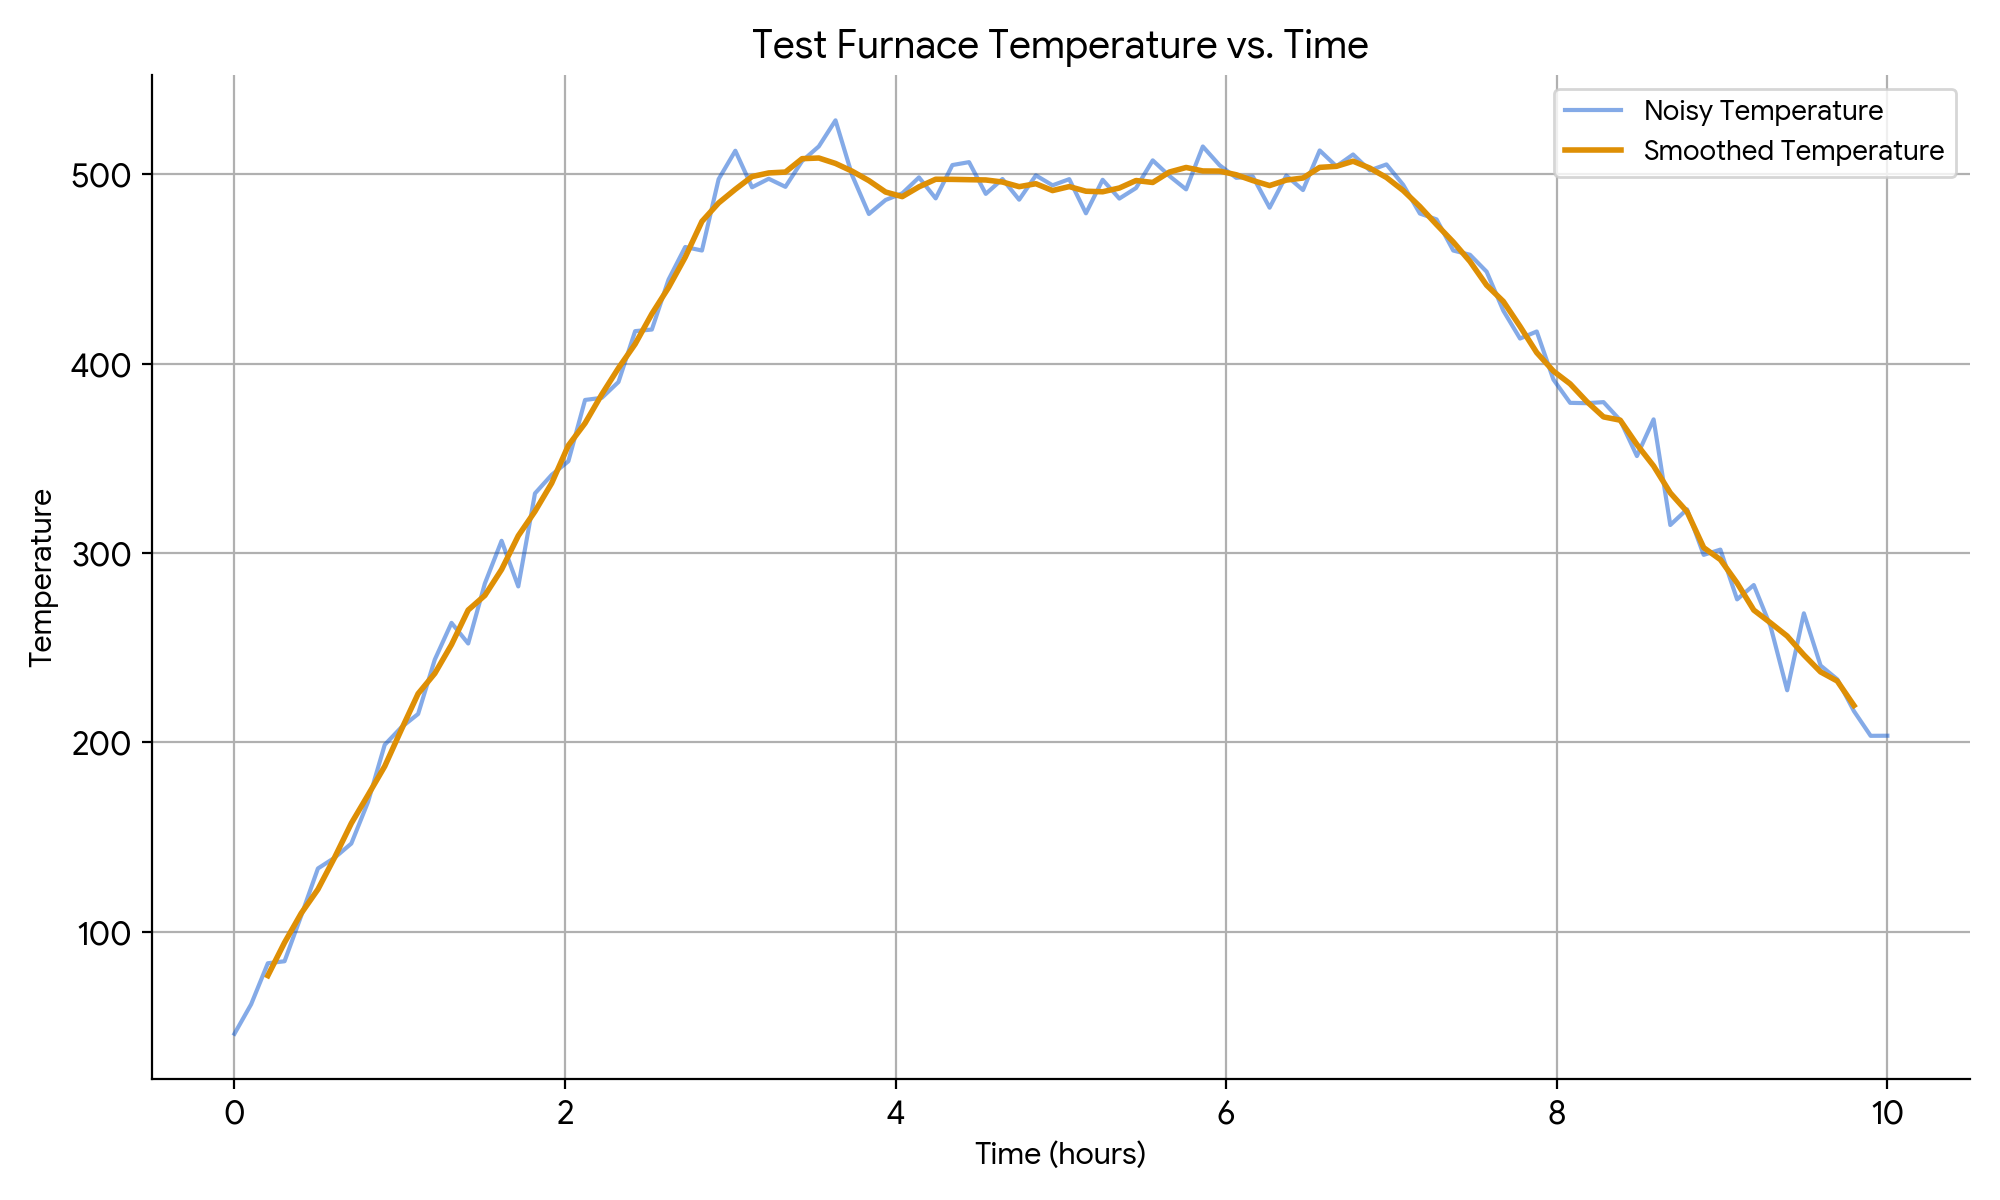

The code generates a plot showing the noisy temperature data and the smoothed temperature data as a function of time. The noisy data is plotted with a lighter color (alpha=0.5) to distinguish it from the smoothed data, which is plotted with a thicker line. A legend, title, and axis labels are included for clarity. A grid is also added to the plot to make it easier to read the values.


In [14]:
handle_response(response)

In [15]:
PROMPT = "Now generate and output descriptive statistics on the time series data."

response = chat.send_message(PROMPT)
handle_response(response)

import numpy as np
import pandas as pd

# Define time range
time = np.linspace(0, 10, 100)  # 100 data points over 10 hours

# Base temperature profile (example: linear heat up, plateau, linear cool down)
temperature = np.zeros_like(time)
for i, t in enumerate(time):
    if t < 3:
        temperature[i] = 50 + 150 * t  # Linear heat up to 50 + 150*3 = 500
    elif t < 7:
        temperature[i] = 500  # Plateau at 500
    else:
        temperature[i] = 500 - 100 * (t - 7)  # Linear cool down

# Add noise
noise = np.random.normal(0, 10, len(time))  # Gaussian noise with std dev 10
temperature += noise

# Create Pandas DataFrame
df = pd.DataFrame({'Time': time, 'Temperature': temperature})

# Calculate moving average (smoothing)
window_size = 5  # Adjust window size as needed
df['Smoothed_Temperature'] = df['Temperature'].rolling(window=window_size, center=True).mean()

# Descriptive statistics
descriptive_stats = df[['Temperature', 'Smoothed_Temperature']].describe()

print(descriptive_s

`       Temperature  Smoothed_Temperature
count   100.000000             96.000000
mean    384.044945            394.341588
std     132.825765            123.354061
min      41.226587             82.468613
25%     290.984145            306.246155
50%     429.374812            449.632686
75%     496.357829            497.960275
max     526.187792            510.501686
`


Outcome:



OUTCOME_OK

The code calculates and prints descriptive statistics for both the noisy temperature data ('Temperature') and the smoothed temperature data ('Smoothed\_Temperature'). The statistics include:

*   **count:** The number of data points. Note that the smoothed temperature has a smaller count because the rolling mean calculation reduces the number of valid data points at the beginning and end of the series.
*   **mean:** The average temperature.
*   **std:** The standard deviation, a measure of the data's spread.
*   **min:** The minimum temperature.
*   **25%:** The first quartile (25th percentile).
*   **50%:** The median (50th percentile or second quartile).
*   **75%:** The third quartile (75th percentile).
*   **max:** The maximum temperature.

These statistics provide a summary of the central tendency, dispersion, and range of the temperature data, both before and after smoothing.


In [16]:
code_execution_tool = Tool(code_execution=ToolCodeExecution())

PROMPT = """
Generate a list of 20 random names, then create a new list with just the names
containing the letter 'a', then output the number of names that contain 'a' and
finally show me that new list.
"""

for chunk in client.models.generate_content_stream(
    model="gemini-2.0-flash-001",
    contents=PROMPT,
    config=GenerateContentConfig(
        tools=[code_execution_tool],
        temperature=0,
    ),
):
    for part in chunk.candidates[0].content.parts:
        if part.text:
            display(Markdown("#### Natural language stream"))
            display(Markdown(part.text))
            display(Markdown("---"))
        if part.executable_code:
            display(Markdown("#### Code stream"))
            display(
                Markdown(
                    f"""
```py
{part.executable_code.code}
```
"""
                )
            )
            display(Markdown("---"))
        if part.code_execution_result:
            display(Markdown("#### Code result"))
            display(
                Markdown(
                    f"""
```
{part.code_execution_result.output}
```
"""
                )
            )
            display(Markdown("---"))

#### Natural language stream

Okay, I can

---

#### Natural language stream

 do that. Here's the process:

1.  **Generate 

...

 \['Alice', 'Charlie', 'David', 'Frank', 'Grace', 'Jack', 'Karen', 'Liam', 'Mia', 'Noah', 'Olivia

---

#### Natural language stream

', 'Ryan', 'Sophia']


---